# PedSilicoICH: Part 2. Scanners

This notebook also introduces concepts of the `Scanners` Class, and assumes familiarity with the [01_phantoms.ipynb](01_phantoms.ipynb) notebook and continues from it.

In [20]:
from insilicoICH import load_phantom
age = 6.5
phantom = load_phantom(age)

import numpy as np
volumes = np.linspace(0.05, 0.5, 3)
intensities = np.linspace(80, 50, 3)
lesion_type = 'IPH'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)

for idx, lesion in enumerate(lesions):
    print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
    phantom.insert_lesion(**lesion)

phantom

inserting lesion 0/3:
{'volume': np.float64(0.05), 'intensity': np.float64(80.0), 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 1/3:
{'volume': np.float64(0.275), 'intensity': np.float64(65.0), 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 2/3:
{'volume': np.float64(0.5), 'intensity': np.float64(50.0), 'lesion_type': 'IPH', 'seed': 336}




        Phantom Class: NIHPD_Head
        Age (years): 0
        Shape (voxels): [189, 233, 197]
        Size (mm): [151.20000225 186.40000278 157.60000235]
        
        Number of lesions: 3
        Lesion locations [voxel index (z, x, y)]: [(np.int64(93), np.int64(175), np.int64(111)), (np.int64(93), np.int64(83), np.int64(131)), (np.int64(92), np.int64(149), np.int64(128))]
        Mass effect: False
        

## Define the scanner that will image the patient phantom

In [21]:
from insilicoICH import Scanner
Scanner?

Init signature:
Scanner(
    phantom: insilicoICH.ground_truth_definition.phantoms.Phantom,
    scanner_model: str = 'Scanner_Default',
    studyname: str = 'default',
    studyid: int = 0,
    seriesname: str = 'default',
    seriesid=0,
    framework: str = 'CATSIM',
    output_dir: str | pathlib.Path = None,
    materials: dict | None = None,
) -> None
Docstring:      A class to hold CT simulation data and run simulations
Init docstring:
:param phantom: Phantom class instance to be scanned, voxels in units of
    approximate CT Numbers [HU], typically in python
    coordinates (z, x, y)
    where z is perpendicular to the axial plane made by x and y.
    See <https://en.wikipedia.org/wiki/Hounsfield_scale>
    for some suggested values for common materials
:param scanner_model: str, study identifier to be used for virtual identifier and DICOM header
:param studyname: str, study identifier to be saved in DICOM header
:param studyid: int, study identifier to be saved in DICOM header
:

In [22]:
scanner = Scanner(phantom, scanner_model='GE_Lightspeed16')
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.800000011920929-mm pixels (XY), 0.800000011920929-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing /tmp/


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: GE_Lightspeed16
        Simulation Platform: CATSIM
        

## Use `scanner.scout_view()` to determine scan range

Here we use the `phantom._lesion_coords` attribute to center the scan around the lesion location to update the center and number of `scans` to the desired scan length

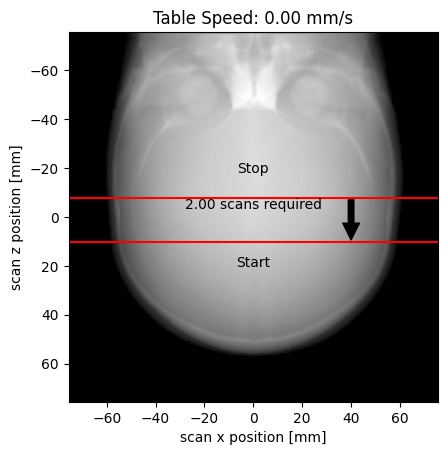

In [23]:
lesion_level_mm = (phantom.get_CT_number_phantom().shape[0]/2 -
                   phantom._lesion_coords[0][0])*phantom.dz

scans = 2  # edit me

center = lesion_level_mm
width = scanner.nominal_aperature*scans
startZ = center - width / 2
endZ = center + width / 2

scanner.scout_view(startZ, endZ)

In [24]:
from insilicoICH.ground_truth_definition.iq_phantoms import DensitometryPhantom

phantom = DensitometryPhantom()
phantom


        Phantom Class: DensitometryPhantom
        Age (years): 0
        Shape (voxels): [1, 400, 400]
        Size (mm): [200.         235.29411765 235.29411765]
        

In [25]:
scanner = Scanner(phantom)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.5882352941176471-mm pixels (XY), 200.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 1 slices...
* Writing volume fraction files for 4 materials and 1 slices, plus the HU data...
* Writing /tmp/tmpy9wccdgi/den


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

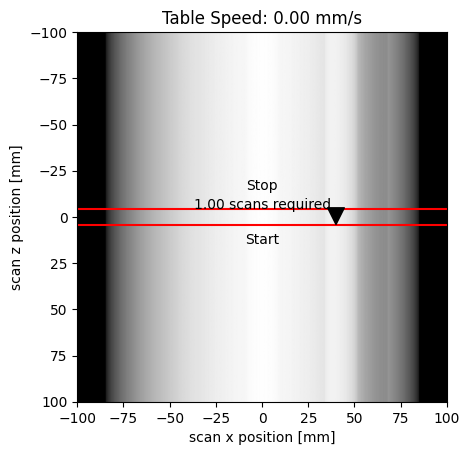

In [26]:
scans = 1
center = 0
width = scanner.nominal_aperature*scans
startZ = center - width / 2
endZ = center + width / 2

scanner.scout_view(startZ, endZ)

Set `pitch=0` for axial scan

In [27]:
acquisition_technique = dict(
    mA=500,
    kVp=120,
    views=1000,
    startZ=startZ,
    endZ=endZ,
    pitch=0
)
scanner.run_scan(**acquisition_technique)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of      2 MB.


100%|██████████| 1000/1000 [09:00<00:00,  1.85it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

In [28]:
recon_technique = dict(
    kernel='soft',
    fov=250,
    sliceThickness=1
)
scanner.run_recon(**recon_technique)

fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (7, 512, 512) 25.0 cm fov
Projections: (1000, 16, 900)

## View the result

In [29]:
%pip install -q matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [30]:
from utils import ctshow

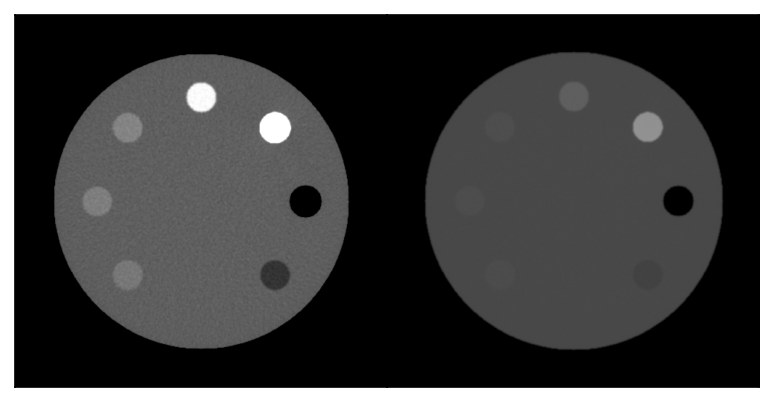

In [31]:
import matplotlib.pyplot as plt
f, axs = plt.subplots(1, 2, gridspec_kw=dict(wspace=0), dpi=150)

idx = len(scanner.recon)//2
ctshow(scanner.recon[idx], 'soft tissues', fig=f, ax=axs[0])
ctshow(scanner.recon[idx], 'temporal bones', fig=f, ax=axs[1])

In [32]:
ctshow(scanner.recon[:, :,256][::-1], 'brain')

In [33]:
from utils import scrollview
scrollview(scanner.recon, 'brain')

interactive(children=(IntSlider(value=3, description='idx', max=6), Output()), _dom_classes=('widget-interact'…

Now set `pitch=0.5` for a helical scan (pitch > 1 currently may introduce artifacts)

In [34]:
acquisition_technique['pitch'] = 0.5
acquisition_technique['views'] = 1000
scanner.run_scan(**acquisition_technique)
scanner.run_recon(**recon_technique)

Airscan
Offset scan
Phantom scan


  0%|          | 0/3000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of      2 MB.


100%|██████████| 3000/3000 [26:59<00:00,  1.85it/s] 


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/9...
   recon slice 1/9...
   recon slice 2/9...
   recon slice 3/9...
   recon slice 4/9...
   recon slice 5/9...
   recon slice 6/9...
   recon slice 7/9...
   recon slice 8/9...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (9, 512, 512) 25.0 cm fov
Projections: (3000, 16, 900)

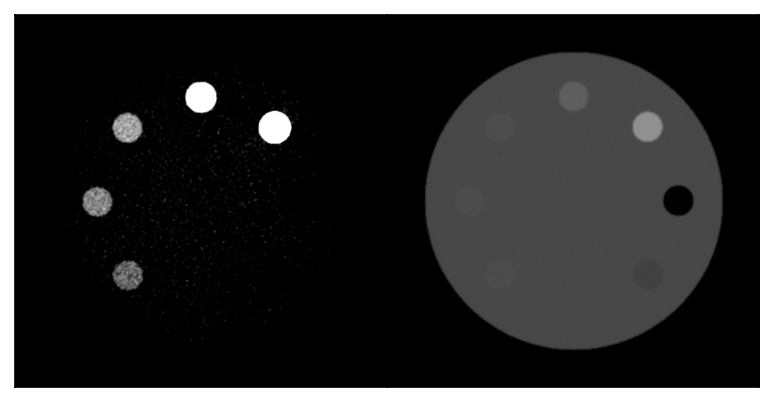

In [35]:
import matplotlib.pyplot as plt
f, axs = plt.subplots(1, 2, gridspec_kw=dict(wspace=0), dpi=150)
ctshow(scanner.recon[len(scanner.recon)//2], 'brain', fig=f, ax=axs[0])
ctshow(scanner.recon[len(scanner.recon)//2], 'temporal bones', fig=f, ax=axs[1])

In [36]:
scrollview(scanner.recon, 'brain')

interactive(children=(IntSlider(value=4, description='idx', max=8), Output()), _dom_classes=('widget-interact'…

Now try a larger 64 slice system

In [37]:
scanner64slice = Scanner(phantom, scanner_model='GE_Lightspeed64')
scanner64slice

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.5882352941176471-mm pixels (XY), 200.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 1 slices...
* Writing volume fraction files for 4 materials and 1 slices, plus the HU data...
* Writing /tmp/tmpivjg7ysd/den


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: GE_Lightspeed64
        Simulation Platform: CATSIM
        

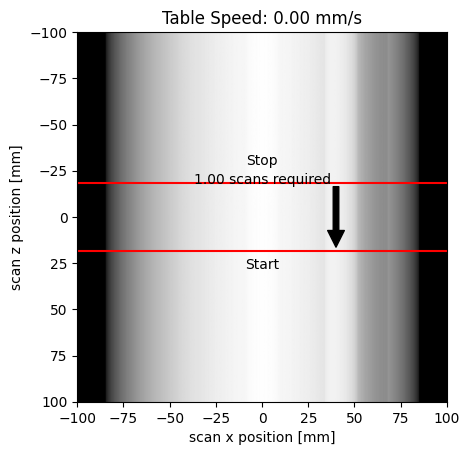

In [38]:
width = scanner64slice.nominal_aperature*scans
startZ = center - width / 2
endZ = center + width / 2

scanner64slice.scout_view(startZ, endZ)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/1000 [00:00<?, ?it/s]

in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of      4 MB.


100%|██████████| 1000/1000 [33:57<00:00,  2.04s/it]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


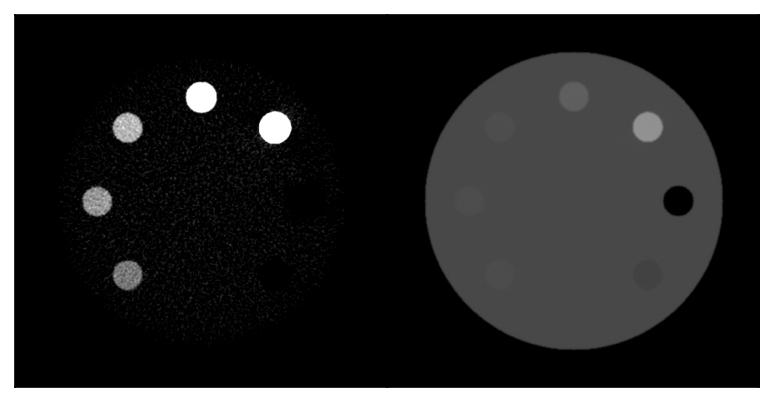

In [40]:
acquisition_technique['pitch'] = 0
scanner64slice.run_scan(**acquisition_technique)
scanner64slice.run_recon(**recon_technique)
f, axs = plt.subplots(1, 2, gridspec_kw=dict(wspace=0), dpi=150)
ctshow(scanner64slice.recon[len(scanner64slice.recon)//2], 'brain', fig=f, ax=axs[0])
ctshow(scanner64slice.recon[len(scanner64slice.recon)//2], 'temporal bones', fig=f, ax=axs[1])

In [41]:
scrollview(scanner64slice.recon, 'brain')

interactive(children=(IntSlider(value=14, description='idx', max=28), Output()), _dom_classes=('widget-interac…

Airscan
Offset scan
Phantom scan


  0%|          | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of      2 MB.


100%|██████████| 1000/1000 [34:07<00:00,  2.05s/it]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/9...
   recon slice 1/9...
   recon slice 2/9...
   recon slice 3/9...
   recon slice 4/9...
   recon slice 5/9...
   recon slice 6/9...
   recon slice 7/9...
   recon slice 8/9...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


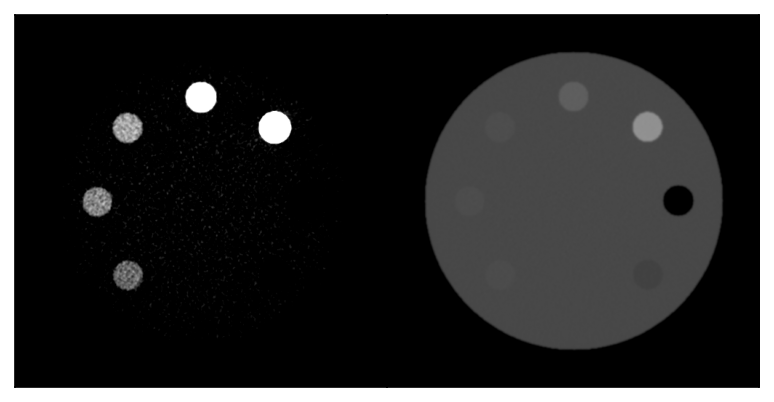

In [42]:
acquisition_technique['pitch'] = 0.5
scanner64slice.run_scan(**acquisition_technique)
scanner64slice.run_recon(**recon_technique)
f, axs = plt.subplots(1, 2, gridspec_kw=dict(wspace=0), dpi=150)
ctshow(scanner64slice.recon[len(scanner64slice.recon)//2], 'brain', fig=f, ax=axs[0])
ctshow(scanner64slice.recon[len(scanner64slice.recon)//2], 'temporal bones', fig=f, ax=axs[1])

## Going Deeper

Below are more advance topics on how to get the lesion mask in the reconstructed image space and exploring more acquisition and reconstruction parameters

In [43]:
scans = 1  # edit me

center = lesion_level_mm
width = scanner.nominal_aperature*scans
startZ = center - width / 2
endZ = center + width / 2
acquisition_technique = dict(
    mA=500,
    kVp=120,
    views=1000,
    startZ=startZ,
    endZ=endZ,
    pitch=0
)

In [44]:
scanner = Scanner(phantom, scanner_model='GE_Lightspeed16')
scanner.run_scan(**acquisition_technique)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.5882352941176471-mm pixels (XY), 200.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 1 slices...
* Writing volume fraction files for 4 materials and 1 slices, plus the HU data...
* Writing /tmp/tmpizwrb6vl/den

  0%|          | 0/1000 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of      2 MB.


100%|██████████| 1000/1000 [08:49<00:00,  1.89it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: GE_Lightspeed16
        Simulation Platform: CATSIM
        

In [45]:
scanner.get_lesion_mask?

Signature:
scanner.get_lesion_mask(
    startZ: int | None = None,
    endZ: int | None = None,
    fov: float | None = None,
    slice_thickness=1,
    **kwargs,
) -> numpy.ndarray[bool]
Docstring:
takes lesion in object space and returns a mask in CT image space
for the given imaging system
File:      ~/repositories/InSilicoICH/src/insilicoICH/image_acquisition.py
Type:      method

In [46]:
scanner.run_recon(**recon_technique)

fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: GE_Lightspeed16
        Simulation Platform: CATSIM
        
Recon: (7, 512, 512) 25.0 cm fov
Projections: (1000, 16, 900)

In [47]:
mask = scanner.get_lesion_mask(**acquisition_technique, **recon_technique)
ctshow(scanner.recon[len(scanner.recon)//2], 'brain')
plt.imshow(mask[len(scanner.recon)//2], cmap='Reds', alpha=0.2)

AttributeError: 'DensitometryPhantom' object has no attribute '_lesion'

In [ ]:
acquisition_technique['pitch'] = 0

In [ ]:
scanner_models = ['GE_LightGE_Lightspeed64', 'Siemens_DefinitionFlash']
scanner_recons = []
for scanner_model in scanner_models:
    scanner = Scanner(phantom, scanner_model='GE_Lightspeed64')
    scanner.run_scan(**acquisition_technique)
    scanner.run_recon(**recon_technique)
    scanner_recons.append(scanner.recon)

In [ ]:
mAs = [20, 80, 320]
mA_recons = []
for mA in mAs:
    scanner.run_scan(mA=mA, startZ=startZ, endZ=endZ, views=1000)
    scanner.run_recon(sliceThickness=1, kernel='soft')
    mA_recons.append(scanner.recon)

In [ ]:
lesion_mask = scanner.get_lesion_mask(startZ=startZ, endZ=endZ)
lesion_mask.shape

In [ ]:
import sys
sys.path.append('..')
from utils import ctshow, center_crop
import matplotlib.pyplot as plt

f, axs = plt.subplots(1, len(scanner_recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, scanner_model in zip(axs.flatten(), scanner_recons, scanner_models):
    ctshow(center_crop(recon[len(recon)//2]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{scanner_model}\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)

In [ ]:
f, axs = plt.subplots(1, len(mA_recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, mA in zip(axs.flatten(), mA_recons, mAs):
    ctshow(center_crop(recon[len(scanner.recon)//2]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{mA} mA\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)

In [ ]:
kVps = [80, 100, 120, 140]
kVp_recons = []
for kVp in kVps:
    mA = 200 * (120 / kVp)**2 # accounts for the fact that tube output scales by kVp^2
    print(f'{kVp} kVp, {mA} mA')
    scanner.run_scan(kVp=kVp, mA=mA, startZ=startZ, endZ=endZ, views=1000)
    scanner.run_recon(sliceThickness=1, kernel='soft')
    kVp_recons.append(scanner.recon)

In [ ]:
f, axs = plt.subplots(1, len(kVp_recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, kVp in zip(axs.flatten(), kVp_recons, kVps):
    ctshow(center_crop(recon[len(scanner.recon)//2]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{kVp} kVp\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)
    

In [ ]:
scanner.run_scan(kVp=120, mA=200, startZ=startZ, endZ=endZ, views=500)

In [ ]:
kernels = ['bone', 'standard', 'soft']

recons = []
for kernel in kernels:
    scanner.run_recon(sliceThickness=1, kernel=kernel)
    recons.append(scanner.recon)

In [ ]:
f, axs = plt.subplots(1, len(recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, kernel in zip(axs.flatten(), recons, kernels):
    ctshow(center_crop(recon[len(scanner.recon)//2]), 'brain', fig=f, ax=ax)
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{kernel}\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)

Effects of Slice Thickness

In [ ]:
slice_thicknesses = [0.5, 1, 1.5, 3, 5]

slice_recons = []
for slice_thickness in slice_thicknesses:
    scanner.run_recon(sliceThickness=slice_thickness, kernel='standard')
    slice_recons.append(scanner.recon)

In [ ]:
f, axs = plt.subplots(1, len(slice_thicknesses), gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
for ax, recon, slice_thickness in zip(axs.flatten(), slice_recons, slice_thicknesses):
    ctshow(center_crop(recon[len(scanner.recon)//2]), 'brain', fig=f, ax=ax)
    # lesion_mask = scanner.get_lesion_mask(startZ=startZ, endZ=endZ)
    # lesion_roi = recon[lesion_mask]
    # mean = lesion_roi.mean()
    # std = lesion_roi.std()
    ax.set_title(f'{slice_thickness} mm', fontsize=6)
    # ax.set_title(f'{slice_thickness} mm\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)

Effects of pitch

In [ ]:
pitches = [0, 0.25, 0.5, 1.0, 1.5, 2]
pitch_recons = []
for pitch in pitches:
    scanner.run_scan(startZ=startZ, endZ=endZ, views=1000, pitch=pitch)
    scanner.run_recon(sliceThickness=1, kernel='soft')
    pitch_recons.append(scanner.recon)

In [ ]:
f, axs = plt.subplots(1, len(pitches), gridspec_kw=dict(wspace=0, hspace=0), dpi=300)
for ax, recon, pitch in zip(axs.flatten(), pitch_recons, pitches):
    ctshow(center_crop(recon[len(scanner.recon)//2]), 'brain', fig=f, ax=ax)
    ax.set_title(f'{pitch} pitch', fontsize=6)

This shows the relation that helical artifacts increase linearly, consistent with [Jiang Hsieh chapter 9.4.1 pg. 402](https://drive.google.com/file/d/1ZhKCiazl8wscNcX_HGdH21jw5koJSB8p/view?usp=sharing):

> For single-slice helical CT, the level of helical-related image artifacts increases
with the helical pitch; that is, a more degraded image quality is expected for
data collected with a higher helical pitch. A higher helical pitch means that the
patient table travels at a greater distance in one gantry rotation. For the same
object, a larger distance between the start and end of scanning locations
generally results in a larger discrepancy or inconsistency in the collected data
(assuming the object is heterogeneous in z). A large inconsistency translates to
a higher level of image artifacts. When the helical pitch approaches zero, we
can revert to the step-and-shoot mode of data collection and no helically
induced image artifacts will be present.

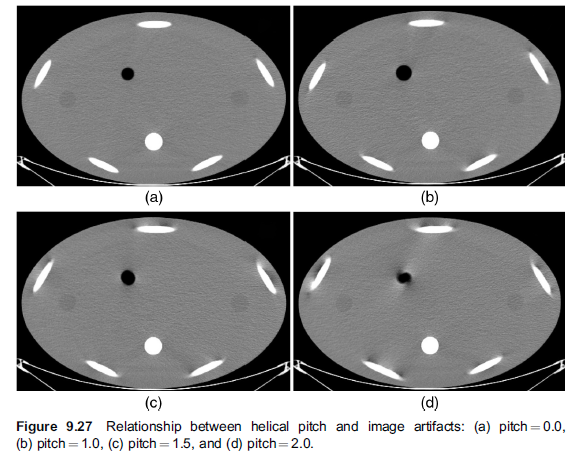

However, it's evident that there is a large difference in reconstructed image quality between XCIST's helical recon and that of the commercial scanner used in the textbook figure. As explained in the chapter, helical recon (especially conebeam helical) is an active research area and there are many approaches to it with varying levels of performance. Thus I suspect, a pitch of 0.5 may be around the limit for XCIST's implementation, their [helical example](https://github.com/xcist/main/blob/master/gecatsim/examples/Sim_Sample_Helical.py) only used a pitch of 0.5, as shown in the calculation below (eq 9.1 from [Jiang Hsieh](https://drive.google.com/file/d/1ZhKCiazl8wscNcX_HGdH21jw5koJSB8p/view?usp=sharing) pg. 380)

In [19]:
tableSpeed = 5.31  # v [mm/s]
rotationTime = 0.5  # t [s]
sid = 540.0  # system geometry to calc magnification
sdd = 950.0  # system geometry to calc magnification
detectorRowSize = 1.0  # system geometry to calc magnification
detectorRowsPerMod = 16  # system geometry to calc magnification
detectorRowCount = detectorRowsPerMod
magnification = sdd/sid
s = detectorRowCount*detectorRowSize/magnification  # s nominal aperature size [mm], aka detector size demagnified at isocenter
h = tableSpeed*rotationTime/s
print(f'pitch = {h}')

pitch = 0.29192708333333334
